In [4]:
import json
import textwrap
import pandas as pd
import numpy as np

PARQUET_FILE = "data_files/flattened_cbo_reports_synonym_match.parquet"   # <-- use the synonym-match parquet
SYNONYM_JSON = "data_files/subcategory_synonyms_word2vec.json"                    # <-- where synonyms were saved

TARGETS = {"Social Security", "Medicaid", "Medicare"}

# ---- adjust these only ----
N_SHOW = 10
TEXT_WIDTH = 110
MAX_LINES = 6

df2 = pd.read_parquet(PARQUET_FILE)

if "matched_phrase" not in df2.columns:
    raise ValueError(
        "This parquet doesn't contain 'matched_phrase'. "
        "Run the synonym/direct-match pipeline that saves matched_phrase + match_method='direct_phrase'."
    )

# -----------------------------
# Load synonyms
# -----------------------------
with open(SYNONYM_JSON, "r", encoding="utf-8") as f:
    synonyms = json.load(f)

# -----------------------------
# Helpers
# -----------------------------
def wrap_text(s, width=TEXT_WIDTH, max_lines=MAX_LINES):
    s = "" if pd.isna(s) else str(s)
    s = " ".join(s.split())
    lines = textwrap.wrap(s, width=width)
    if len(lines) > max_lines:
        lines = lines[:max_lines] + ["...[truncated]"]
    return "\n".join(lines)

def print_rows(title, out, n=N_SHOW, sort_col=None, ascending=False):
    print("\n" + title)
    if out.empty:
        print("(none)")
        return

    if sort_col is not None and sort_col in out.columns:
        out = out.sort_values(sort_col, ascending=ascending)

    out = out.head(n).copy()
    out["text"] = out["text"].apply(wrap_text)

    for _, r in out.iterrows():
        print("-" * 100)
        print(f"{r.get('report_name','?')} | para {r.get('paragraph_number','?')}")
        print(f"subcategory: {r.get('subcategory', pd.NA)} | matched_phrase: {r.get('matched_phrase', pd.NA)} | method: {r.get('match_method', pd.NA)}")
        print(r["text"])

def norm(x):
    return "" if pd.isna(x) else str(x).strip().lower()


# -----------------------------
# 2) Summary: how many target matches are direct_phrase vs literal etc.
# -----------------------------
print("\n=== COUNTS FOR TARGETS ===")
print(df2[df2["subcategory"].isin(TARGETS)]["match_method"].value_counts(dropna=False))

# -----------------------------
# 3) Show matches that specifically came from a synonym (not the official label)
# -----------------------------
target_matches = df2[
    df2["subcategory"].isin(TARGETS) &
    df2["subcategory"].notna()
].copy()

target_matches["is_synonym_hit"] = target_matches.apply(
    lambda r: norm(r["matched_phrase"]) != norm(r["subcategory"]),
    axis=1
)

syn_hits = target_matches[target_matches["is_synonym_hit"] == True].copy()

print("\n=== SYNONYM-HIT COUNTS (which generated phrases are actually triggering matches) ===")
if syn_hits.empty:
    print("(none)  -> Either (a) no synonym phrases are matching, or (b) matched_phrase is always the exact label.")
else:
    print(
        syn_hits.groupby(["subcategory", "matched_phrase"])
        .size()
        .sort_values(ascending=False)
        .head(25)
        .to_string()
    )

# -----------------------------
# 4) Example paragraphs for synonym hits (overall + per target)
# -----------------------------
print_rows(
    title="Examples: synonym-triggered matches (all targets)",
    out=syn_hits[["report_name","paragraph_number","match_method","subcategory","matched_phrase","text"]],
    n=N_SHOW,
)

for t in sorted(TARGETS):
    ex = syn_hits[syn_hits["subcategory"] == t][
        ["report_name","paragraph_number","match_method","subcategory","matched_phrase","text"]
    ]
    print_rows(
        title=f"Examples: synonym-triggered matches for {t}",
        out=ex,
        n=N_SHOW,
    )

# -----------------------------
# 5) (Optional) show “exact label” hits too, so you can compare
# -----------------------------
exact_hits = target_matches[target_matches["is_synonym_hit"] == False].copy()
print_rows(
    title="Examples: exact-label matches (for comparison)",
    out=exact_hits[["report_name","paragraph_number","match_method","subcategory","matched_phrase","text"]],
    n=N_SHOW,
)


=== COUNTS FOR TARGETS ===
match_method
direct_phrase_w2v_neighbors    2570
Name: count, dtype: int64

=== SYNONYM-HIT COUNTS (which generated phrases are actually triggering matches) ===
subcategory      matched_phrase                
Medicare         health_care                       344
                 prescription_drug                  86
                 Medicare_beneficiaries             49
Social Security  Social_Secu_rity                   40
                 pensions                           33
Medicaid         MediCal                            29
                 uninsured                          24
Medicare         Medicare_Advantage                 22
Social Security  Social_Se_curity                   16
Medicaid         Medicaid_enrollees                 16
Social Security  Social_Security_Administration     16
Medicare         Medicare_enrollees                 15
                 Medicare_Prescription_Drug         11
                 Medicare_Part                  

In [5]:
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Files
# ------------------------------------------------------------
IN_PARQUET  = "data_files/flattened_cbo_reports_synonym_match.parquet"
OUT_PARQUET = "data_files/flattened_cbo_reports_synonym_match_with_embeddings.parquet"

# ------------------------------------------------------------
# Load synonym-match results
# ------------------------------------------------------------
df = pd.read_parquet(IN_PARQUET).reset_index(drop=True)

if "text" not in df.columns:
    raise ValueError("Input parquet must contain a 'text' column.")
if "matched_phrase" not in df.columns:
    print("Warning: no 'matched_phrase' column found. Plot 2 (exact vs synonym) will not work as intended.")

# ------------------------------------------------------------
# Load Word2Vec + stopwords
# ------------------------------------------------------------
import gensim.downloader as api
import nltk
from nltk.corpus import stopwords

try:
    stop_words = set(stopwords.words("english"))
except LookupError:
    nltk.download("stopwords", quiet=True)
    stop_words = set(stopwords.words("english"))

cbo_fillers = {"billion","million","percent","year","years","fiscal","estimate","estimated","cbo"}
stop_words.update(cbo_fillers)

w2v_model = api.load("word2vec-google-news-300")
vector_size = w2v_model.vector_size

def get_mean_vector(text, model, size):
    raw_words = [w.strip(",.?!()\"';:") for w in str(text).lower().split()]
    words = [w for w in raw_words if w and w not in stop_words]
    vecs = [model[w] for w in words if w in model]
    if not vecs:
        return np.zeros(size, dtype=np.float32)
    return np.mean(vecs, axis=0).astype(np.float32)

# ------------------------------------------------------------
# Compute embeddings (chunked)
# ------------------------------------------------------------
texts = df["text"].astype(str).tolist()
E = np.zeros((len(df), vector_size), dtype=np.float32)

chunk_size = 2000
for start in range(0, len(texts), chunk_size):
    chunk = texts[start:start+chunk_size]
    E[start:start+len(chunk)] = np.array(
        [get_mean_vector(t, w2v_model, vector_size) for t in chunk],
        dtype=np.float32
    )

# Store embeddings in parquet-friendly form
df["embedding"] = [v.tolist() for v in E]
df["embedding_model"] = "word2vec-google-news-300"
df["embedding_dim"] = int(vector_size)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
df.to_parquet(OUT_PARQUET, index=False, engine="pyarrow", compression="zstd")
print(f"Saved: {OUT_PARQUET}")
print("Rows:", len(df), "| Embedding dim:", vector_size)

Saved: data_files/flattened_cbo_reports_synonym_match_with_embeddings.parquet
Rows: 23248 | Embedding dim: 300


Rows plotted: 6566
Explained variance (PC1, PC2): [0.09858911 0.08141989]


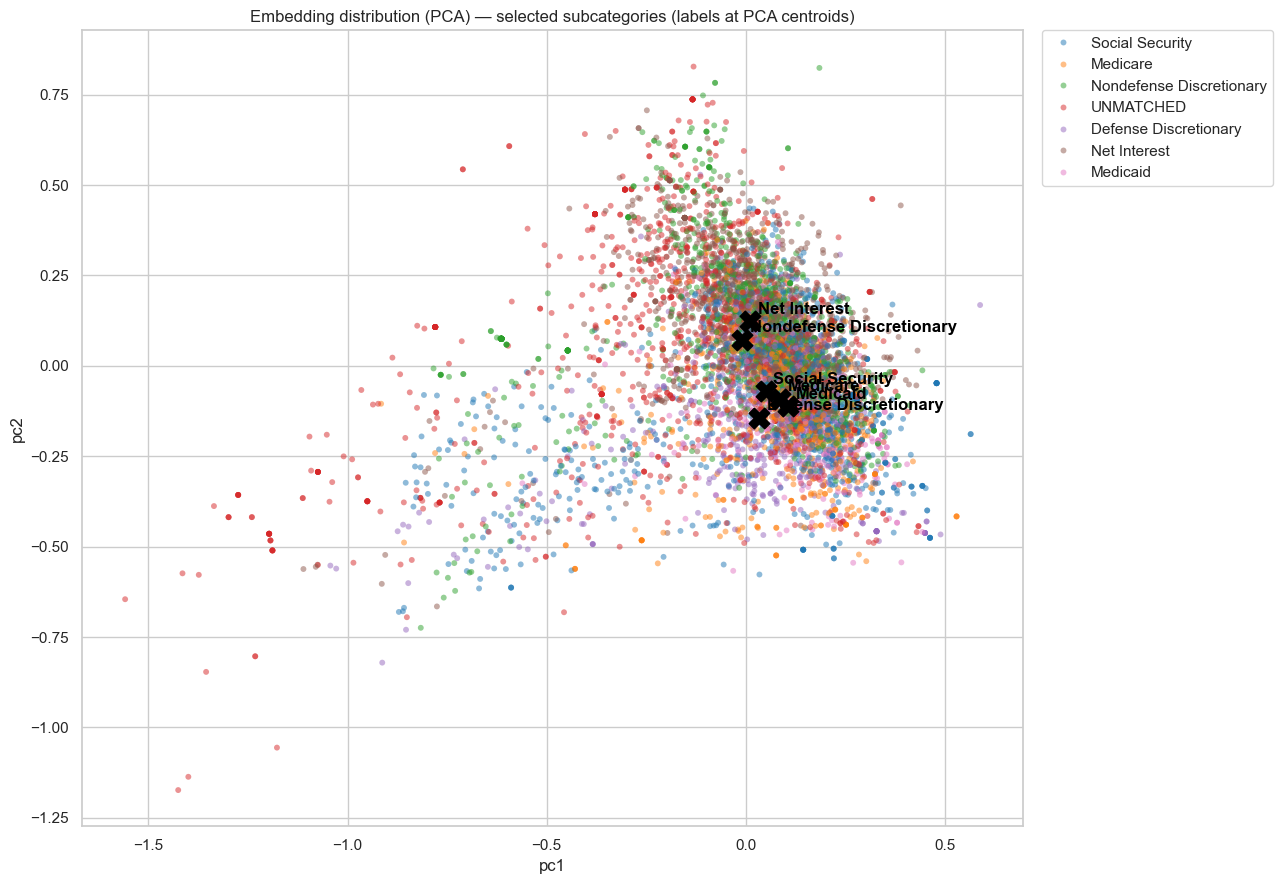

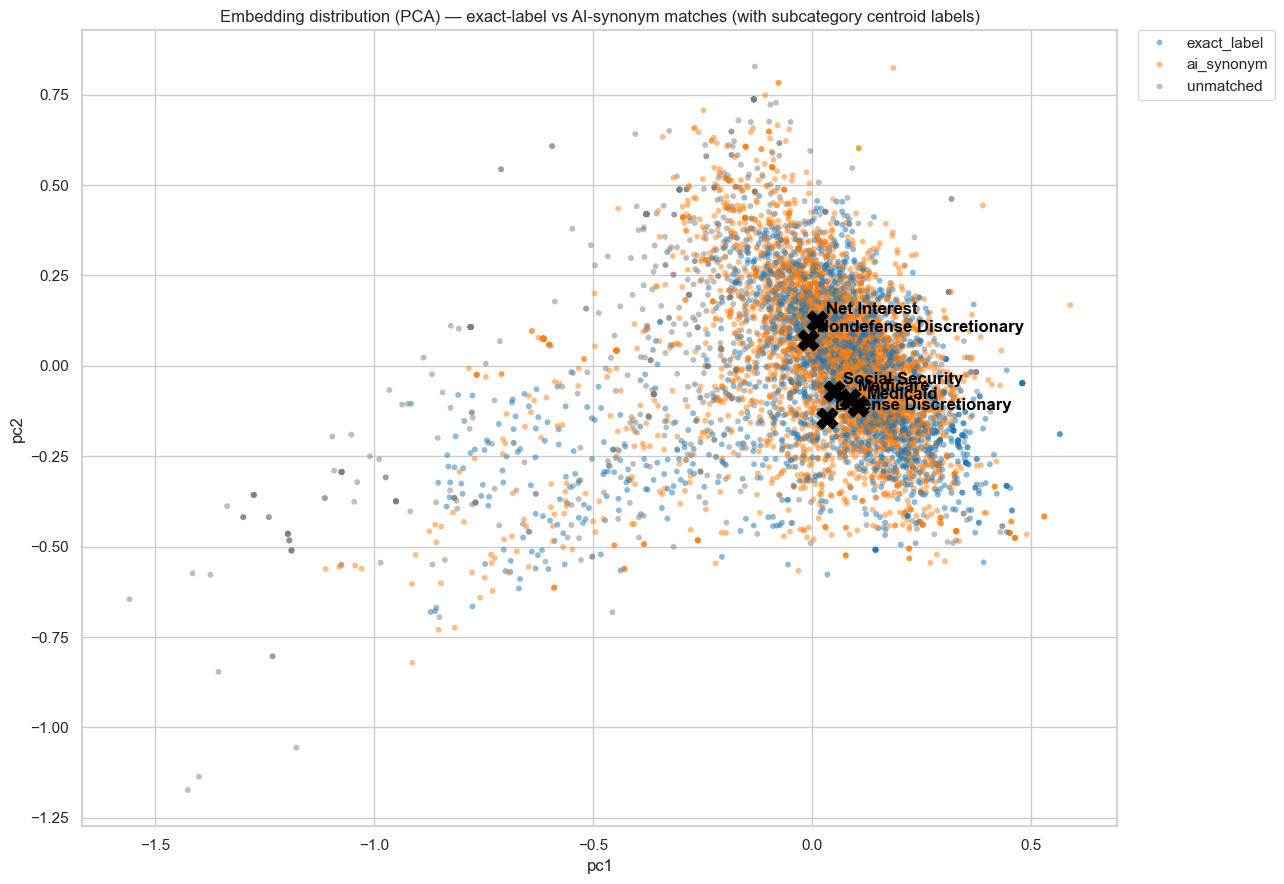

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

# ============================================================
# Inputs / knobs (adjust these)
# ============================================================
PARQUET_FILE = "data_files/flattened_cbo_reports_synonym_match_with_embeddings.parquet"

# only keep these labels (plus UNMATCHED if INCLUDE_UNMATCHED=True)
FOCUS_SUBCATEGORIES = {
    "Medicare",
    "Medicaid",
    "Social Security",
    "Defense Discretionary",
    "Nondefense Discretionary",
    "Net Interest",
}

INCLUDE_UNMATCHED = True

# sampling
MAX_PER_SUBCATEGORY = 1200
RANDOM_STATE = 1

ALPHA = 0.50
POINT_SIZE = 18

# centroid label placement
SHOW_SUBCATEGORY_LABELS = True
LABEL_FONT_SIZE = 12

# ============================================================
# Load
# ============================================================
df = pd.read_parquet(PARQUET_FILE)

required = {"embedding", "subcategory", "matched_phrase"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing columns in parquet: {missing}")

E = np.array(df["embedding"].to_list(), dtype=np.float32)

# ============================================================
# Filter to focus subcategories (+ optional unmatched)
# ============================================================
plot_df = df.copy()

if INCLUDE_UNMATCHED:
    keep_mask = plot_df["subcategory"].isin(FOCUS_SUBCATEGORIES) | plot_df["subcategory"].isna()
else:
    keep_mask = plot_df["subcategory"].isin(FOCUS_SUBCATEGORIES)

plot_df = plot_df[keep_mask].copy()

plot_df["subcategory_plot"] = plot_df["subcategory"].astype("object").where(
    plot_df["subcategory"].notna(), "UNMATCHED"
)

# align embeddings to filtered df
E_plot_full = E[plot_df.index.to_numpy()]

# ============================================================
# Balanced sampling per subcategory (including UNMATCHED)
# ============================================================
parts = []
rng = np.random.RandomState(RANDOM_STATE)

for sub, g in plot_df.groupby("subcategory_plot"):
    n = min(MAX_PER_SUBCATEGORY, len(g))
    parts.append(g.sample(n=n, random_state=RANDOM_STATE))

plot_df = pd.concat(parts, axis=0).sample(frac=1, random_state=RANDOM_STATE).reset_index()
E_plot = E[plot_df["index"].to_numpy()]

# ============================================================
# PCA -> 2D coordinates
# ============================================================
pca = PCA(n_components=2, random_state=RANDOM_STATE)
XY = pca.fit_transform(E_plot)

plot_df["pc1"] = XY[:, 0]
plot_df["pc2"] = XY[:, 1]

print("Rows plotted:", len(plot_df))
print("Explained variance (PC1, PC2):", pca.explained_variance_ratio_)

# ============================================================
# Match type (for plot 2)
# ============================================================
def norm(x):
    return "" if pd.isna(x) else str(x).strip().lower()

plot_df["match_type"] = "unmatched"
has_label = plot_df["subcategory"].notna()
exact = has_label & (plot_df["matched_phrase"].apply(norm) == plot_df["subcategory"].apply(norm))
syn = has_label & ~exact
plot_df.loc[exact, "match_type"] = "exact_label"
plot_df.loc[syn, "match_type"] = "ai_synonym"

# ============================================================
# Compute 2D centroid locations for subcategory labels
# (mean of points in PCA space)
# ============================================================
cent2d = (
    plot_df[plot_df["subcategory_plot"] != "UNMATCHED"]
    .groupby("subcategory_plot")[["pc1", "pc2"]]
    .mean()
    .reset_index()
)

# ============================================================
# Plot 1: colored by subcategory + label centroid locations
# ============================================================
plt.figure(figsize=(13, 9))
palette1 = sns.color_palette("tab10", n_colors=plot_df["subcategory_plot"].nunique())

sns.scatterplot(
    data=plot_df,
    x="pc1", y="pc2",
    hue="subcategory_plot",
    alpha=ALPHA,
    s=POINT_SIZE,
    linewidth=0,
    palette="tab10"
)

if SHOW_SUBCATEGORY_LABELS:
    for _, r in cent2d.iterrows():
        plt.scatter(r["pc1"], r["pc2"], s=220, c="black", marker="X", zorder=5)
        plt.text(
            r["pc1"] + 0.02, r["pc2"] + 0.02,
            r["subcategory_plot"],
            fontsize=LABEL_FONT_SIZE,
            weight="bold",
            color="black",
            zorder=6
        )

plt.title("Embedding distribution (PCA) — selected subcategories (labels at PCA centroids)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2: colored by match type + label centroid locations
# ============================================================
plt.figure(figsize=(13, 9))
palette2 = {
    "exact_label": "#1f77b4",
    "ai_synonym":  "#ff7f0e",
    "unmatched":   "#7f7f7f",
}

sns.scatterplot(
    data=plot_df,
    x="pc1", y="pc2",
    hue="match_type",
    palette=palette2,
    alpha=ALPHA,
    s=POINT_SIZE,
    linewidth=0
)

if SHOW_SUBCATEGORY_LABELS:
    for _, r in cent2d.iterrows():
        plt.scatter(r["pc1"], r["pc2"], s=220, c="black", marker="X", zorder=5)
        plt.text(
            r["pc1"] + 0.02, r["pc2"] + 0.02,
            r["subcategory_plot"],
            fontsize=LABEL_FONT_SIZE,
            weight="bold",
            color="black",
            zorder=6
        )

plt.title("Embedding distribution (PCA) — exact-label vs AI-synonym matches (with subcategory centroid labels)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()